## 2D Patchy Particles

We will implement a basic system for the self-assembly of two-dimensional patchy particles.

In [107]:
from jax_md import space, smap, energy, minimize, quantity, simulate, rigid_body
import jax.numpy as np
from jax import random, jit, lax, vmap, grad, config
config.update('jax_enable_x64', True)

import matplotlib.pyplot as plt
from tqdm import tqdm

import matplotlib as mpl
mpl.rcParams['text.usetex'] = True
# Further customization, e.g., fonts:
mpl.rcParams['font.family'] = 'serif'

### 2D Lennard-Jones Crystallization

In [108]:
N = 128
dimension = 2
box_size = quantity.box_size_at_number_density(N, 0.2, dimension)
dt = 2e-3
T = 100

# disp_fn, shift_fn = space.free() # for space without boundaries or periodicity
disp_fn, shift_fn = space.periodic(box_size) # for periodic space
steps = int(T / dt)
max_time = steps * dt
kT = lambda t: 0.1

In [109]:
key = random.PRNGKey(0)
key, split = random.split(key)

R = random.uniform(
    split, (N, dimension), minval=0.0, maxval=box_size
)

particle_diameter = 1

In [110]:
# use soft sphere repulsion to separate particles out, so we don't get weird numerical bugs when running our actual simulation.
energy_fn = energy.soft_sphere_pair(disp_fn, sigma=particle_diameter)
init_fn, apply_fn = minimize.fire_descent(energy_fn, shift_fn)

state = init_fn(R)
apply_fn_jit = jit(lambda i, state: apply_fn(state))
state = lax.fori_loop(0, 5000, apply_fn_jit, state)

# this should be treated as the actual initial position of the particles.
R = state.position

In [111]:
energy_fn = energy.lennard_jones_pair(disp_fn, sigma=particle_diameter)
# force_fn = quantity.force(energy_fn)

# routine for simulation via NVT dynamics
init_fn, apply_fn = simulate.nvt_nose_hoover(energy_fn, shift_fn, kT=kT(0), dt=dt)
state = init_fn(key, R)

In [112]:
write_every = 100

# taken straight from JAX-MD docs.
def step_fn(i, state_and_log):
  state, log = state_and_log
  t = i * dt

  # Log information about the simulation.
  T = quantity.temperature(momentum=state.momentum)
  log['kT'] = log['kT'].at[i].set(T)
  H = simulate.nvt_nose_hoover_invariant(energy_fn, state, kT(t))
  log['H'] = log['H'].at[i].set(H)

  # Record positions every `write_every` steps.
  log['position'] = lax.cond(
    i % write_every == 0,
    lambda p: p.at[i // write_every].set(state.position),
    lambda p: p,
    log['position'],
  )

  # Take a simulation step.
  state = apply_fn(state, kT=kT(t))

  return state, log

In [113]:
log = {
  'kT': np.zeros((steps,)),
  'H': np.zeros((steps,)),
  'position': np.zeros((steps // write_every,) + R.shape),
}

state, log = lax.fori_loop(0, steps, step_fn, (state, log))

R = state.position

In [116]:
def plot_2d_particles(R, box_size, particle_diameter):
    radius = particle_diameter / 2
    fig, ax = plt.subplots()

    # Draw each particle as a circle
    for x, y in R:
        circle = plt.Circle((x, y), radius, fill=False)
        ax.add_patch(circle)

    # Set box limits
    ax.set_xlim(0, box_size)
    ax.set_ylim(0, box_size)

    # Make sure aspect ratio is equal (so circles stay circles)
    ax.set_aspect('equal')

    # Optional: draw box boundary
    ax.plot([0, box_size, box_size, 0, 0],
            [0, 0, box_size, box_size, 0])

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("2D Particle Configuration")
    plt.show()

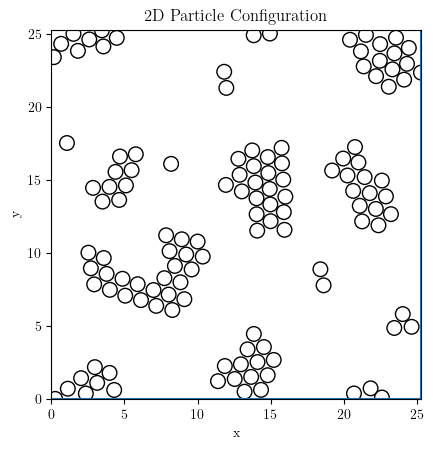

In [117]:
plot_2d_particles(log['position'][-1], box_size, particle_diameter)

### Trying to Figure out how Rigid Bodies Work

In [57]:
particle_diameter = 1.0
patch_distance = particle_diameter / 2 # 0.5

body_points = np.array([
    [0.0, 0.0], # core position of particle
    [patch_distance, 0.0], # patch on the right
    [-patch_distance, 0.0] # patch on the left
])

In [58]:
species = np.array([0, 1, 2]) # three different species
# 0 -> core, 1 -> right patch, 2 -> left patch

In [59]:
shape = rigid_body.point_union_shape(body_points, species)

In [60]:
# setting up the space and particles
N = 50
box_size = quantity.box_size_at_number_density(N, 0.2, 2)

disp_fn, shift_fn = space.periodic(box_size)

In [61]:
key = random.PRNGKey(0)
centers = random.uniform(key, (N, 2), minval=0.0, maxval=box_size)
orientations = random.uniform(key, (N,), minval=0.0, maxval=2*np.pi)
# in theory, we could do: orientations = np.zeros((N,))

In [62]:
# separate out the particles using soft-sphere repulsion
energy_fn = energy.soft_sphere_pair(disp_fn, sigma=particle_diameter)
init_fn, apply_fn = minimize.fire_descent(energy_fn, shift_fn)

state = init_fn(centers)
apply_fn_jit = jit(lambda i, state: apply_fn(state))
state = lax.fori_loop(0, 5000, apply_fn_jit, state)

# this should be treated as the actual initial position of the particles.
centers = state.position

In [63]:
R = rigid_body.RigidBody(centers, orientations)

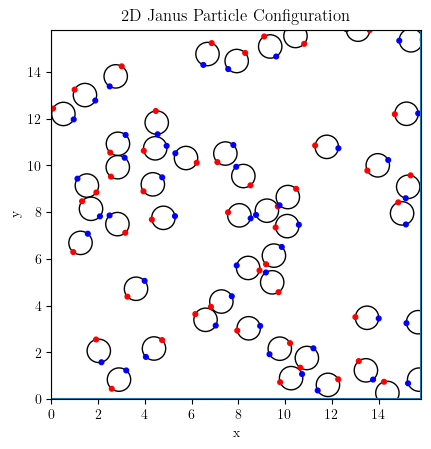

In [64]:
def plot_janus_particles(centers, orientations, body_points, species, box_size):
    fig, ax = plt.subplots()

    for center, orientation in zip(centers, orientations):
        # Compute the positions of the body points for this particle
        rotation_matrix = np.array([
            [np.cos(orientation), -np.sin(orientation)],
            [np.sin(orientation), np.cos(orientation)]
        ])
        rotated_body_points = body_points @ rotation_matrix.T
        particle_points = center + rotated_body_points

        # Draw each point as a circle with color based on species
        for point, sp in zip(particle_points, species):
            color = 'red' if sp == 1 else 'blue' if sp == 2 else 'black'
            circle = plt.Circle(point, radius=0.5 if color=='black' else 0.1, color=color, fill=True if color != 'black' else False)
            ax.add_patch(circle)

    # Set box limits
    ax.set_xlim(0, box_size)
    ax.set_ylim(0, box_size)

    # Make sure aspect ratio is equal (so circles stay circles)
    ax.set_aspect('equal')

    # Optional: draw box boundary
    ax.plot([0, box_size, box_size, 0, 0],
            [0, 0, box_size, box_size, 0])

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("2D Janus Particle Configuration")
    plt.show()

plot_janus_particles(centers, orientations, body_points, species, box_size)

In [91]:
epsilon_matrix = np.array([
    [1.0, 0.0, 0.0],   # core interactions
    [0.0, 5.0, 0.0],   # red
    [0.0, 0.0, 5.0],   # blue
]) # interactions between different species, such that cores interact with cores, but red <-> red and blue <-> blue are the only interactions present otherwise. They are attractive by LJ potential.

The only real pathway I see to implementing this is to implement the forces and functions and updates manually. The notebook from Brenner's group is too confusing for me to fully understand, and seems to be using an outdated version of JAX-MD. I'll just try to manually implement 2D crystallization again, this time relying little on the prebuilt energy functions.

### Reimplementing 2D Lennard-Jones Crystallization (More Manually)

In [118]:
N = 128
dimension = 2
box_size = quantity.box_size_at_number_density(N, 0.2, dimension)
dt = 2e-3
T = 100

# disp_fn, shift_fn = space.free() # for space without boundaries or periodicity
disp_fn, shift_fn = space.periodic(box_size) # for periodic space
steps = int(T / dt)
max_time = steps * dt
kT = lambda t: 0.1

In [119]:
key = random.PRNGKey(0)
key, split = random.split(key)

def generate_initial_positions(N, dimension, box_size, particle_diamter, key=random.PRNGKey(0)):
    key, split = random.split(key)
    R = random.uniform(
        split, (N, dimension), minval=0.0, maxval=box_size
    )

    energy_fn = energy.soft_sphere_pair(disp_fn, sigma=particle_diameter)
    init_fn, apply_fn = minimize.fire_descent(energy_fn, shift_fn)

    state = init_fn(R)
    apply_fn_jit = jit(lambda i, state: apply_fn(state))
    state = lax.fori_loop(0, 5000, apply_fn_jit, state)

    return state.position

particle_diamter = 1.0
R = generate_initial_positions(N, dimension, box_size, particle_diameter, key=key)

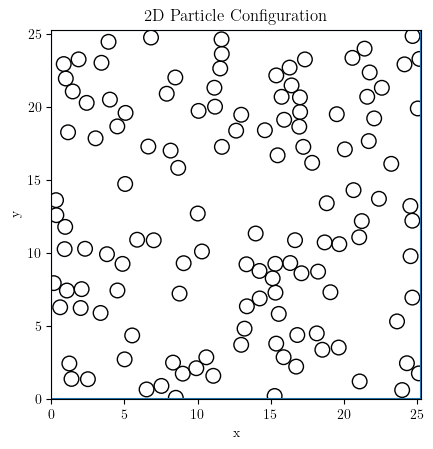

In [120]:
plot_2d_particles(R, box_size, particle_diameter)